<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Matrix Review**


Matrix operations are a fundamental part of machine learning and many fields, such as digital signal processing, optimization, control systems, computer graphics, and so on. As a result, there has been a lot of work on optimizing matrix operations, not only in software, but in hardware. Let's say you work for a AI hardware  company, the company has developed a new processor that can only perform matrix operations. The company needs you to implement some popular  statistics such as mean, variance and Principle Component Analysis using Matrix operations


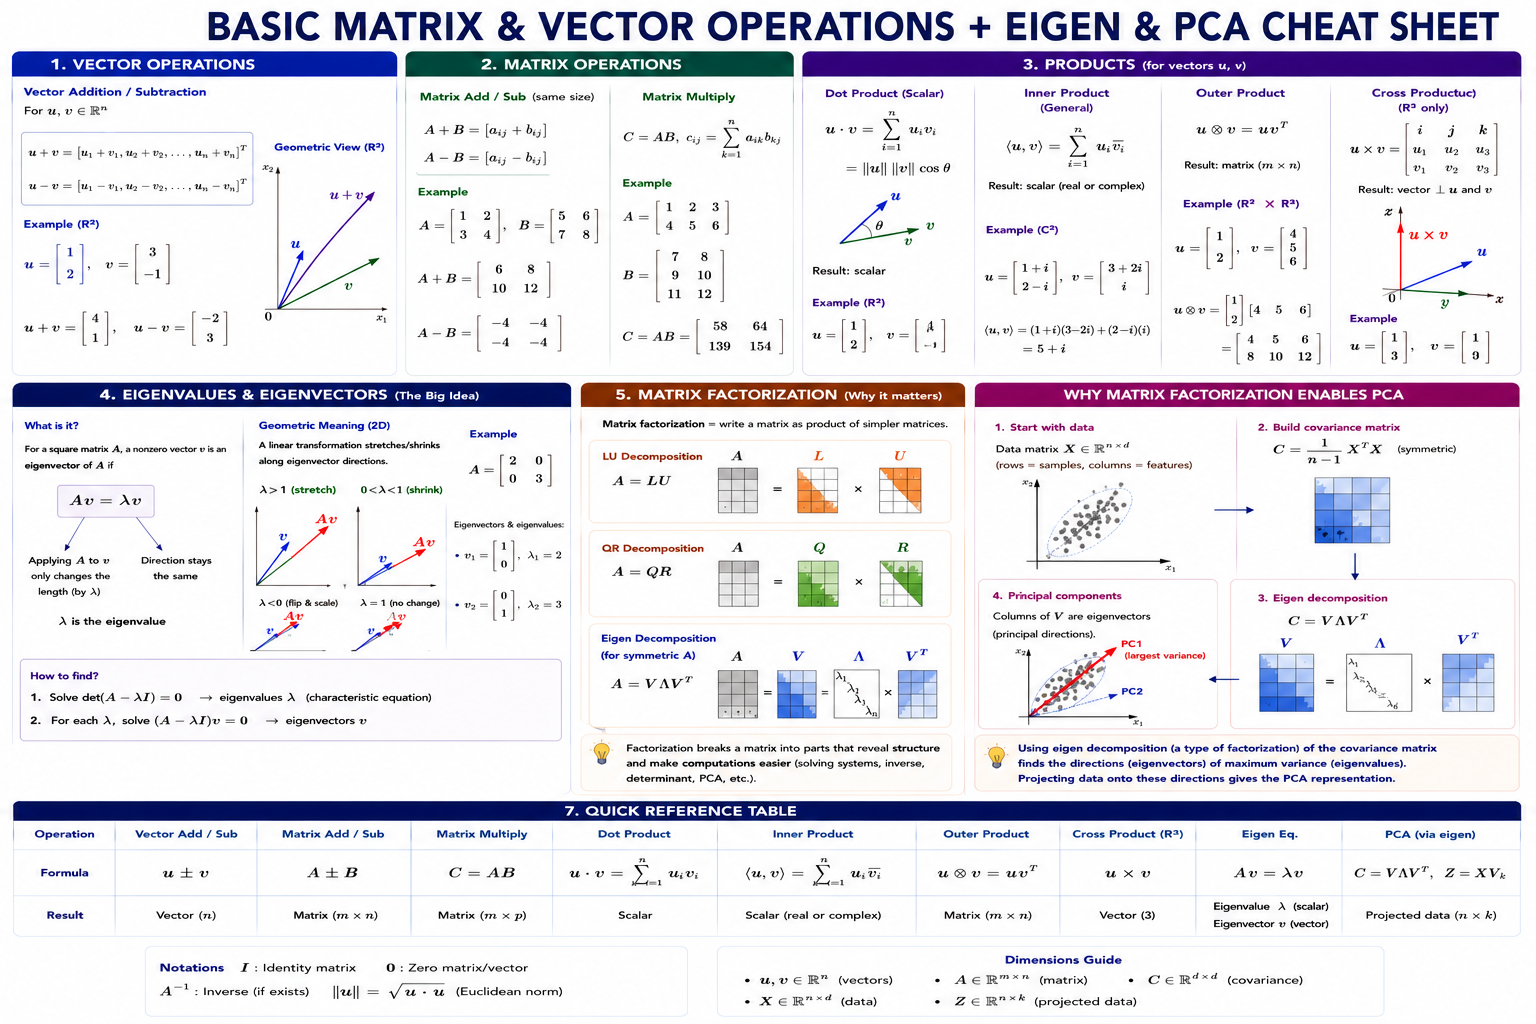

## __Table of Contents__

1. [Objectives](<#Objectives>)
2. [Setup](<#Setup>)
    1. [Installing required libraries](<#Installing-required-libraries>)
    2. [Importing required libraries](<#Importing-required-libraries>)
    3. [Defining Helper Functions](<#Defining-Helper-Functions>)
3. [Basics of Matrices](<#Basics-of-Matrices>)
    1. [What's a Matrix](<#What's-a-Matrix>)
    2. [Rank of a Matrix](<#Rank-of-a-Matrix>)
    3. [Frobenius Norm of a Matrix](<#Frobenius-Norm-of-a-Matrix>)
    4. [Matrix Addition](<#Matrix-Addition>)
4. [Matrix and Vector Multiplication](<#Matrix-and-Vector-Multiplication>)
    1. [Dot-Product](<#Dot-Product>)
    2. [Exercise 1](<#Exercise-1>)
    3. [The Outer product](<#The-Outer-product>)
    4. [Exercise 2](<#Exercise-2>)
    5. [Outer Product vs Dot Product](<#Outer-Product-vs-Dot-Product>)
    6. [Matrix and Vector Multiplication](<#Matrix-and-Vector-Multiplication>)
    7. [Multiplying Matrices](<#Multiplying-Matrices>)
    8. [Matrix Inverse](<#Matrix-Inverse>)
    9. [Exercise 3](<#Exercise-3>)
    10. [Exercise 4](<#Exercise-4>)
5. [Eigen Decomposition](<#Eigen-Decomposition>)
    1. [Eigenvectors and Eigenvalues](<#Eigenvectors-and-Eigenvalues>)
6. [Factorization for PCA](<#Factorization-for-PCA>)
    1. [Exercise 5](<#Exercise-5>)
    2. [Exercise 6](<#Exercise-6>)


***


## **Objectives**

After completing this lab you will be able to:

*   **Understand** Basic Matrix operations such as Matrix addition, Vector Multiplication  Eigen decomposition

*   **Apply** Apply these Matrix operations using numpy


## **Setup**


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for mathematical operations.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for visualizing the data.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for machine learning and machine-learning-pipeline related functions.


### **Installing required libraries**


The following required modules are pre-installed in the Skills Network Labs environment. However, if you run this notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda) you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [79]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install pandas ==1.3.4 ..."

You can install and use  <a href="https://www.sympy.org/en/index.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01">SymPy </a> to print matrices


!conda install -c anaconda sympy -y

### **Importing required libraries**


In [ ]:
# Surpress warnings from using older version of sklearn:
def warn(*args, **kwargs):
    pass


import warnings

warnings.warn = warn

import numpy as np
import matplotlib.pylab as plt

from sklearn.decomposition import PCA
from sympy import Matrix, init_printing, Symbol
from numpy.linalg import qr, eig, inv, matrix_rank, inv, norm
from scipy.linalg import null_space

import pandas as pd

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 10)
init_printing()

### **Defining Helper Functions**

*Use this section to define any helper functions to help the notebook's code readability:*


In [81]:
def plot_2d(dict_):
    for key, value in dict_.items():
        if value.shape[0] > 2:
            plt.scatter(value[:, 0], value[:, 1], label=key)
        else:
            print(value)
            plt.quiver([0], [0], value[:, 0], value[:, 1], label=key)

    plt.legend()
    plt.show()

## **Basics of Matrices**


### **What's a Matrix**


Numpy treats matrix objects as numpy arrays, so we will use Numpy to create matrices. Let's consider the square matrix A.


**NOTE**: We use the function `Matrix` to print out the Matrix , each column of matrix has two columns: Matrix $\mathbf{A}=[\mathbf{a}*{1},\mathbf{a}*{2}]$


In [82]:
A = np.array([[2, -3], [4, 7]])

Matrix(A)

⎡2  -3⎤
⎢     ⎥
⎣4  7 ⎦

In [83]:
a1 = A[:, 0]
a1

array([2, 4])

In [84]:
Matrix(a1)

⎡2⎤
⎢ ⎥
⎣4⎦

In [85]:
a2 = A[:, 1]
a2

array([-3,  7])

In [86]:
Matrix(a2)

⎡-3⎤
⎢  ⎥
⎣7 ⎦

Denoted by $A^{T}$, the transpose of a matrix  switches the row and column indices of the matrix, in numpy we can determine the transpose of $A$ as follows:


In [87]:
AT = A.T
Matrix(AT)

⎡2   4⎤
⎢     ⎥
⎣-3  7⎦

### **Rank of a Matrix**


The rank of a matrix is the number of **dimension** the rows of the matrix "live in".  You can verify the Matrix truly behaves like a  square matrix if it's <a href='https://en.wikipedia.org/wiki/Rank_(linear_algebra)?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01'>rank</a> is equal to the number of rows or columns, then it is referred to as **full rank**.


In [88]:
matrix_rank(A)

2

We can plot the columns of $A$ as vectors.


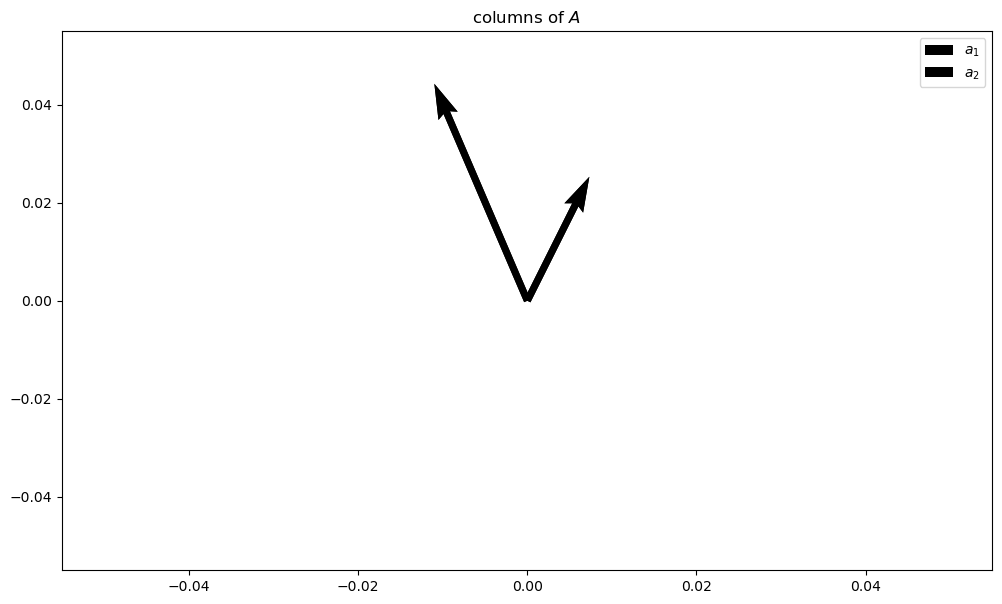

In [89]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.quiver([0, 0], [0, 0], A[0, 0], A[1, 0], scale=30, label="$a_{1}$")
ax.quiver([0, 0], [0, 0], A[0, 1], A[1, 1], scale=30, label="$a_{2}$")
plt.title("columns of $A$ ")
plt.legend()
plt.show()

As the vectors are not parallel, we can define any point on the 2d space as a scaled  combination of those two vectors.

If any of the columns in a matrix  are multiples of each other, the vectors point in the same direction and the matrix is not full rank.


In [90]:
F = np.array([[2, 4], [4, 8]])
matrix_rank(F)

1

In [91]:
Matrix(F)

⎡2  4⎤
⎢    ⎥
⎣4  8⎦

We see the columns are pointing  in the same direction


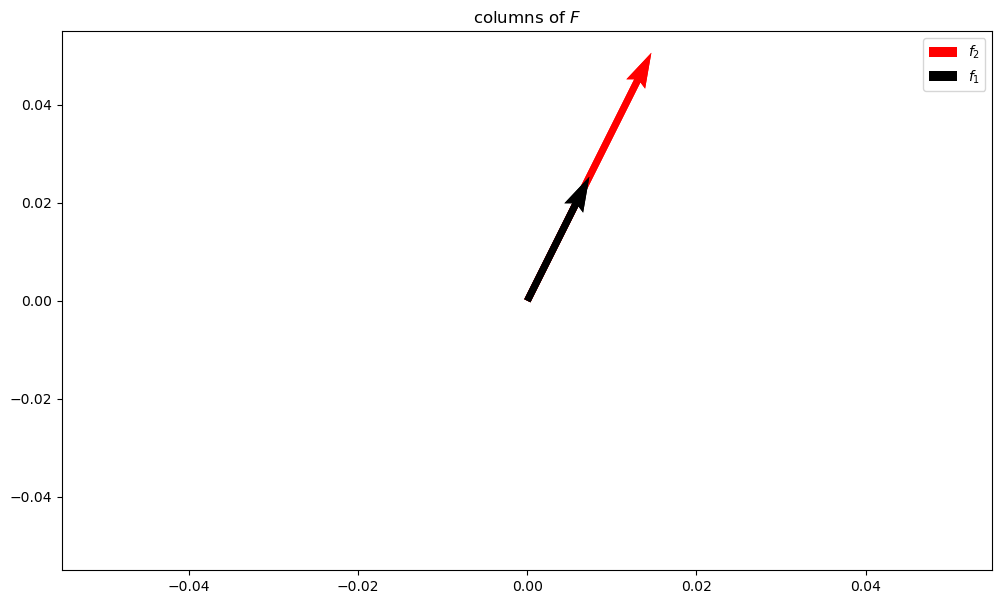

In [92]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.quiver(
    [0, 0], [0, 0], F[0, 1], F[1, 1], scale=30, label="$f_{2}$", color="red"
)
ax.quiver([0, 0], [0, 0], F[0, 0], F[1, 0], scale=30, label="$f_{1}$")
plt.title("columns of $F$ ")
plt.legend()
plt.show()

A common occurance is a matrix with more columns than rows, but in data, more rows than columns is more common. Consider the matrix $F$.


In [93]:
F = np.array([[1, 2], [1, -2], [-1, 1]])
Matrix(F)

⎡1   2 ⎤
⎢      ⎥
⎢1   -2⎥
⎢      ⎥
⎣-1  1 ⎦

Although, the rows of matrix $F$ are 3 dimensions, you can only describe the point lying in the 2D plane, as shown here:


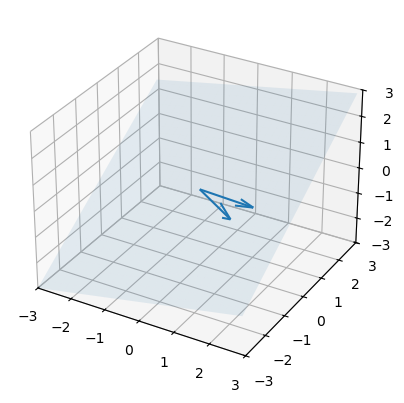

In [94]:
ax = plt.figure().add_subplot(projection="3d")
p = null_space(F.T)
xx, yy = np.meshgrid(np.arange(-3, 3, 0.1), np.arange(-3, 3, 0.1))
z = (p[0] * xx + p[1] * yy) / p[2]
ax.plot_surface(xx, yy, z, alpha=0.1)
ax.quiver([0, 0], [0, 0], [0, 0], F[0, :], F[1, :], F[2, :])

ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.set_zlim([-3, 3])
plt.show()

Therefore, the rank is 2.


In [95]:
matrix_rank(F)

2

### **Frobenius Norm of a Matrix**


The Frobenius norm, sometimes also called the **Euclidean norm**, is the matrix norm of an $m×n$. Matrix A is defined as the square root of the sum of the absolute squares of its elements:

For a vector, the Euclidean norm represents the vector's length.

For a matrix, the idea is similar, but the matrix treat the entire matrix itself as one point in a higher-dimensional space.

It is defined as: $$\|A\|_F = \sqrt{\sum_{i=1}^{m}\sum_{j=1}^{n}|a_{ij}|^2}$$

where:

- $A$ is a matrix
- $a_{ij}$ is the element in row $i$, column $j$
- $m$ and $n$ are the numbers of rows and columns

The calculation is simple:

1. Square every element in the matrix
2. Add all squared values together
3. Take the square root

For example:

$$A=
\begin{bmatrix}
1 & 2 \\
3 & 4
\end{bmatrix}$$

For the Frobenius norm, we temporarily flatten the matrix: $A=[1,2,3,4]$, so  the matrix becomes one point Then we can define a Euclidean length for the entire matrix.

$$\|A\|_F = \sqrt{1^2+2^2+3^2+4^2} = \sqrt{30}$$

The Frobenius norm is the matrix version of Euclidean distance for vectors.
Let's use the matrix A again as an example:


In [96]:
Matrix(A), norm(A)

⎛⎡2  -3⎤                   ⎞
⎜⎢     ⎥, 8.831760866327848⎟
⎝⎣4  7 ⎦                   ⎠

You could also calculate the matrix norm manually, using the formula provided above, and confirm that the results are the same.


In [97]:
m, n = A.shape[0], A.shape[1]  # get number of rows and columns
ss = 0

for i in range(m):
    for j in range(n):
        ss += A[i, j] ** 2
np.sqrt(ss)

### **Matrix Addition**


Consider matrix $B$:


In [98]:
B = np.array([[1, 1], [1, -1]])
Matrix(B)

⎡1  1 ⎤
⎢     ⎥
⎣1  -1⎦

In general, if we have matrix $\mathbf{A}$ and matrix $\mathbf{B}$


$\begin{align}
\mathbf{A}= \begin{bmatrix}
a\_{11} & a\_{12} & \cdots & a\_{1n} \\\\\\
a\_{21} & a\_{22} & \cdots & a\_{2n} \\\\\\
\vdots & \vdots & \ddots & \vdots \\\\\\
a\_{m1} & a\_{m2} & \cdots & a\_{mn} \\\\\\
\end{bmatrix}
\end{align}$
$\begin{align}
\mathbf{B}=\begin{bmatrix}
b\_{11} & b\_{12} & \cdots & b\_{1n} \\\\\\
b\_{21} & b\_{22} & \cdots & b\_{2n} \\\\\\
\vdots & \vdots & \ddots & \vdots \\\\\\
b\_{m1} & b\_{m2} & \cdots & b\_{mn} \\\\\\
\end{bmatrix}
\end{align}$


To be added, the two matrices must have an equal number of rows and columns, where we add the corresponding row and column element:


$\begin{align}
\mathbf{A}+\mathbf{B}=\begin{bmatrix}
a\_{11} + b\_{11} & a\_{12} + b\_{12} & \cdots & a\_{1n} + b\_{1n} \\\\\\
a\_{21} + b\_{21} & a\_{22} + b\_{22} & \cdots & a\_{2n} + b\_{2n} \\\\\\
\vdots & \vdots & \ddots & \vdots \\\\\\
a\_{m1} + b\_{m1} & a\_{m2} + b\_{m2} & \cdots & a\_{mn} + b\_{mn} \\\\\\
\end{bmatrix}
\end{align}$


In numpy, we can add two arrays as follows:


In [99]:
C = A + B
Matrix(C)

⎡3  -2⎤
⎢     ⎥
⎣5  6 ⎦

**Symmetric matrix** means $B=B^{T}$, we can verify this in Python:


In [100]:
B_T = B.T
Matrix(B_T)

⎡1  1 ⎤
⎢     ⎥
⎣1  -1⎦

Arbitrary semantic matrix $S=C+C^T$, where $C$ is any matrix.


In [101]:
C = np.random.randn(2, 2)
S = C + C.T

In [102]:
Matrix(S)

⎡-0.0123450122639169  -0.649926330153134⎤
⎢                                       ⎥
⎣-0.649926330153134   -2.68106468292645 ⎦

In [103]:
Matrix(S.T)

⎡-0.0123450122639169  -0.649926330153134⎤
⎢                                       ⎥
⎣-0.649926330153134   -2.68106468292645 ⎦

<b>Diagonal matrix</b> is a matrix in which the entries outside of the main diagonal are all zero.


In [104]:
Matrix(np.diag(np.array([1, 2, 3])))

⎡1  0  0⎤
⎢       ⎥
⎢0  2  0⎥
⎢       ⎥
⎣0  0  3⎦

If the main diagonal is one, it's called a identity matrix in numpy.


In [105]:
Matrix(np.eye(3))

⎡1.0  0.0  0.0⎤
⎢             ⎥
⎢0.0  1.0  0.0⎥
⎢             ⎥
⎣0.0  0.0  1.0⎦

## **Matrix and Vector Multiplication**


### **Dot-Product**


We can define a vector as a one dimensional array of $\mathbf{a}$ and $\mathbf{b}$, and we can find the dot product of the two as follows:


$ a^T  b = \sum\_{i=1}^n a_i b_i = a\_1 b\_1 + \cdots + a_n b_n$


Where  $\mathbf{a}$ and  $\mathbf{b}$ have the same length, in numpy:


In [106]:
a = np.array([1, 1])
b = np.array([1, 2])

In [107]:
Matrix(a), Matrix(b)

⎛⎡1⎤  ⎡1⎤⎞
⎜⎢ ⎥, ⎢ ⎥⎟
⎝⎣1⎦  ⎣2⎦⎠

We can verify that the dimension is one.


In [108]:
a.ndim

Find the dot product


In [109]:
a @ b

3

If the array is 2- dimension, the order matters. $a^{T}$ must be a row vector of shape $1xm$ and $b$ a column vector of shape $mx1$.


$a^{T} = \begin{bmatrix}
a\_{1},a\_{2},..,a\_{n}
\end{bmatrix}$

$b = \begin{bmatrix}
b\_{1} \\\\\\
b\_{2} \\\\\\
\vdots \\\\\\
b\_{n}
\end{bmatrix}$


In [110]:
a = np.array([[1], [1]])
b = np.array([[1], [2]])
Matrix(a.T @ b)

[3]

### **Exercise 1**

Calculate the dot product of $a$ and $one$.


In [111]:
Matrix(a)

⎡1⎤
⎢ ⎥
⎣1⎦

In [112]:
one = np.ones(2)

Matrix(one)

⎡1.0⎤
⎢   ⎥
⎣1.0⎦

In [113]:
# TO DO
Matrix(one @ a)

[2.0]

In [114]:
one.shape, a.shape

### **The Outer product**


The outer product is another useful matrix operation. Consider the matrix or vector $ \mathbf{u}$ of size $nx1$ and matrix or vector $\mathbf{v}$ $1xm$. Then their outer product is:


$
\mathbf{u} \otimes \mathbf{v} = \mathbf{u}\mathbf{v}^\textsf{T} =
\begin{bmatrix}u\_1 \\\\\ u\_2 \ \vdots\ u_n\end{bmatrix}
\begin{bmatrix}v\_1 & .. & v_m\end{bmatrix} =
\begin{bmatrix}
u\_1 v\_1 & .. & u\_1 v_m\\\\\\
u\_2 v\_1 & u\_2 v\_2 & u\_2 v\_3 \\\\\\
\vdots   & \ddots & \vdots \\\\\\
u_n v\_1 &  .. & u_n v_m
\end{bmatrix}.
$


We can perform the outer product in numpy as follows


In [115]:
u = np.array([[1], [2], [3], [4]])
v = np.array([[0], [1], [2], [3], [6]])
# TO DO
Matrix(u), Matrix(v)

⎛     ⎡0⎤⎞
⎜⎡1⎤  ⎢ ⎥⎟
⎜⎢ ⎥  ⎢1⎥⎟
⎜⎢2⎥  ⎢ ⎥⎟
⎜⎢ ⎥, ⎢2⎥⎟
⎜⎢3⎥  ⎢ ⎥⎟
⎜⎢ ⎥  ⎢3⎥⎟
⎜⎣4⎦  ⎢ ⎥⎟
⎝     ⎣6⎦⎠

In [116]:
Matrix(np.outer(u, v))

⎡0  1  2  3   6 ⎤
⎢               ⎥
⎢0  2  4  6   12⎥
⎢               ⎥
⎢0  3  6  9   18⎥
⎢               ⎥
⎣0  4  8  12  24⎦

In [117]:
np.outer(u, v)

array([[ 0,  1,  2,  3,  6],
       [ 0,  2,  4,  6, 12],
       [ 0,  3,  6,  9, 18],
       [ 0,  4,  8, 12, 24]])

In [118]:
Matrix(u @ v.T)

⎡0  1  2  3   6 ⎤
⎢               ⎥
⎢0  2  4  6   12⎥
⎢               ⎥
⎢0  3  6  9   18⎥
⎢               ⎥
⎣0  4  8  12  24⎦

### **Exercise 2**

Create a matrix with 4 columns where each even column is  the vector  `u`  or else it is  zero, show the rank is one:


In [119]:
u = np.array([[1], [2]])
# TO DO
Matrix(u), Matrix(np.array([[0, 1, 0, 1]]))

⎛⎡1⎤              ⎞
⎜⎢ ⎥, [0  1  0  1]⎟
⎝⎣2⎦              ⎠

In [120]:
Matrix(u @ np.array([[0, 1, 0, 1]]))

⎡0  1  0  1⎤
⎢          ⎥
⎣0  2  0  2⎦

<details>
    <summary>Click here for Solution</summary>

```python
Matrix(u@np.array([[0,1,0,1]]))
```

</details>


### **Outer Product vs Dot Product**
Suppose:

$$\mathbf{u} =
\begin{bmatrix}
u_1 \\
u_2 \\
u_3
\end{bmatrix},
\quad
\mathbf{v} =
\begin{bmatrix}
v_1 \\
v_2 \\
v_3
\end{bmatrix}$$

The **dot product** is:
$$\mathbf{u}^\mathsf{T}\mathbf{v} = u_1v_1 + u_2v_2 + u_3v_3$$

The result is:
$$
\textbf{a single number (scalar)}
$$

Geometrically, the dot product measures:
- similarity of directions
- projection
- alignment between vectors

The **outer product** is:

$$\mathbf{u}\mathbf{v}^\mathsf{T}$$

Here:
- $\mathbf{u}$ is a column vector
- $\mathbf{v}^\mathsf{T}$ is a row vector

Multiplying them produces a matrix:
$$
\begin{bmatrix}
u_1 v_1 & u_1 v_2 & u_1 v_3 \\
u_2 v_1 & u_2 v_2 & u_2 v_3 \\
u_3 v_1 & u_3 v_2 & u_3 v_3
\end{bmatrix}
$$

The result is:
$$
\textbf{a matrix}
$$
not a scalar.

**Dot Product** measures:
```text
How similar are the two vector directions?
```
**Outer Product** builds a matrix describing:
```text
All pairwise interactions between vector components
```
This is commonly used in:
- covariance matrices
- neural networks
- tensor operations
- low-rank matrix construction
- PCA and SVD

### **Matrix and Vector Multiplication**


Matrix-vector multiplication takes a matrix and a vector as inputs and returns a new vector.

Suppose $\mathbf{A}$ has $m$ rows and $n$ columns. To multiply $\mathbf{A}\mathbf{x}$, the vector $\mathbf{x}$ must have $n$ entries. The result $\mathbf{b}$ will have $m$ entries, one for each row of $\mathbf{A}$.

Let the vector $\mathbf{x}$ be:


$$
\mathbf{x}=
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{bmatrix}
$$


Then $\mathbf{A}\mathbf{x}=\mathbf{b}$ is computed by taking the dot product of each row of $\mathbf{A}$ with $\mathbf{x}$.

If

$$
\mathbf{A} =
\begin{bmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{bmatrix},
\quad
\mathbf{x} =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{bmatrix}
$$

then:


$$
\mathbf{b} = \mathbf{A}\mathbf{x} =
\begin{bmatrix}
a_{11}x_1 + a_{12}x_2 + \cdots + a_{1n}x_n \\
a_{21}x_1 + a_{22}x_2 + \cdots + a_{2n}x_n \\
\vdots \\
a_{m1}x_1 + a_{m2}x_2 + \cdots + a_{mn}x_n
\end{bmatrix}
$$


So the output vector is:


$$
\mathbf{b}=
\begin{bmatrix}
b_1 \\
b_2 \\
\vdots \\
b_m
\end{bmatrix}
$$


In NumPy, the <code>@</code> operator performs this multiplication:


In [121]:
x = np.array([1, 1])
Matrix(x)

⎡1⎤
⎢ ⎥
⎣1⎦

In [122]:
A = np.array([[-1, 1], [1, 2]])
Matrix(A)

⎡-1  1⎤
⎢     ⎥
⎣1   2⎦

In [123]:
b = A @ x
Matrix(b)

⎡0⎤
⎢ ⎥
⎣3⎦

For this example:

$$
\mathbf{A} =
\begin{bmatrix}
-1 & 1 \\
1 & 2
\end{bmatrix},
\quad
\mathbf{x} =
\begin{bmatrix}
1 \\
1
\end{bmatrix}
$$

The first entry of $\mathbf{b}$ is the dot product of the first row of $\mathbf{A}$ with $\mathbf{x}$:

$$
b_1 = (-1)(1) + (1)(1) = 0
$$

The second entry is the dot product of the second row of $\mathbf{A}$ with $\mathbf{x}$:

$$
b_2 = (1)(1) + (2)(1) = 3
$$

Therefore:

$$
\mathbf{b} =
\begin{bmatrix}
0 \\
3
\end{bmatrix}
$$

Another useful view is that $\mathbf{A}\mathbf{x}$ is a weighted sum of the columns of $\mathbf{A}$. If $\mathbf{a}_1$ and $\mathbf{a}_2$ are the columns of $\mathbf{A}$, then:

$$
\mathbf{A}\mathbf{x} = x_1\mathbf{a}_1 + x_2\mathbf{a}_2
$$

Here, $x_1=x_2=1$, so $\mathbf{b}$ is the sum of the two columns of $\mathbf{A}$.


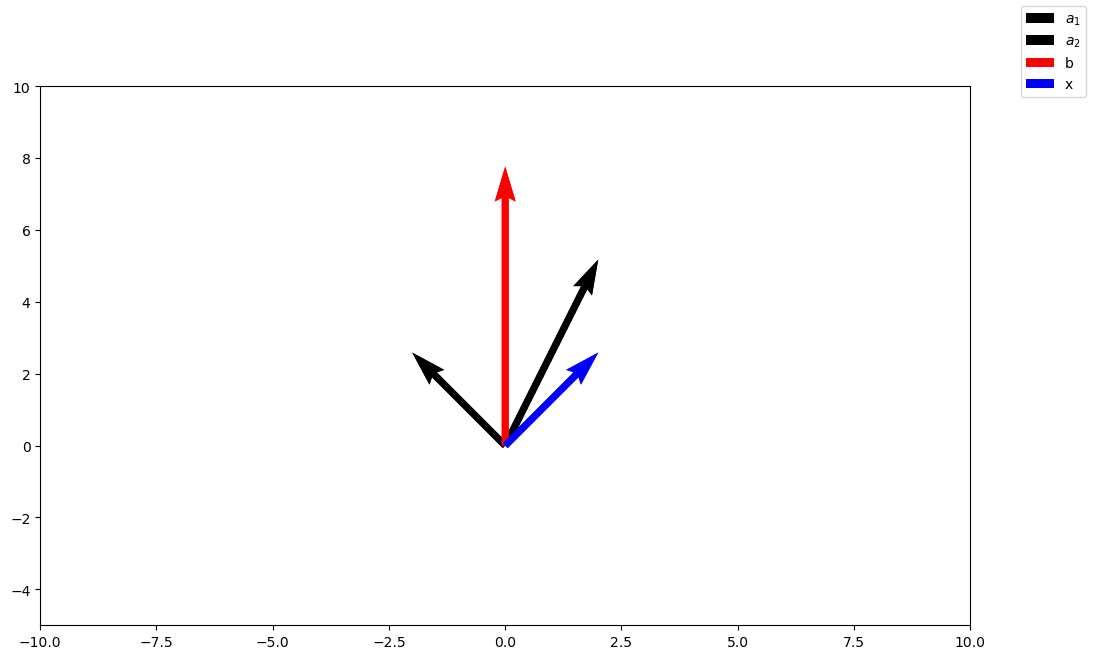

In [124]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.quiver([0, 0], [0, 0], A[0, 0], A[1, 0], scale=10, label="$a_{1}$")
ax.quiver([0, 0], [0, 0], A[0, 1], A[1, 1], scale=10, label="$a_{2}$")
ax.quiver([0, 0], [0, 0], b[0], b[1], scale=10, label="b", color="r")
ax.quiver([0, 0], [0, 0], x[0], x[1], scale=10, label="x", color="b")
ax.set_xlim([-10, 10])
ax.set_ylim([-5, 10])
fig.legend()
plt.show()

### **Multiplying Matrices**


Matrix-matrix multiplication repeats the same row-dot-column idea many times.

Suppose $\mathbf{A}$ has shape $m \times n$ and $\mathbf{B}$ has shape $n \times p$:

$$
\mathbf{A} \in \mathbb{R}^{m \times n},
\quad
\mathbf{B} \in \mathbb{R}^{n \times p}
$$

The inner dimensions must match. Here, both inner dimensions are $n$, so the product is defined. The result $\mathbf{C}=\mathbf{A}\mathbf{B}$ has shape $m \times p$:

$$
\mathbf{C} \in \mathbb{R}^{m \times p}
$$

Each entry $c_{ij}$ is found by taking the dot product of row $i$ of $\mathbf{A}$ with column $j$ of $\mathbf{B}$:

$$
c_{ij} = \sum_{k=1}^{n} a_{ik}b_{kj}
$$

The index $k$ moves across the columns of $\mathbf{A}$ and down the rows of $\mathbf{B}$.


Written out, the product is:

$$
\mathbf{C}=\mathbf{A}\mathbf{B}=
\begin{bmatrix}
c_{11} & c_{12} & \cdots & c_{1p} \\
c_{21} & c_{22} & \cdots & c_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
c_{m1} & c_{m2} & \cdots & c_{mp}
\end{bmatrix}
$$

where, for example:

$$
c_{11} = a_{11}b_{11} + a_{12}b_{21} + \cdots + a_{1n}b_{n1}
$$

$$
c_{12} = a_{11}b_{12} + a_{12}b_{22} + \cdots + a_{1n}b_{n2}
$$

$$
c_{ij} = a_{i1}b_{1j} + a_{i2}b_{2j} + \cdots + a_{in}b_{nj}
$$

So every entry of $\mathbf{C}$ is one dot product.


In [125]:
Matrix(A), Matrix(B)

⎛⎡-1  1⎤  ⎡1  1 ⎤⎞
⎜⎢     ⎥, ⎢     ⎥⎟
⎝⎣1   2⎦  ⎣1  -1⎦⎠

In [126]:
C = A @ B
Matrix(C)

⎡0  -2⎤
⎢     ⎥
⎣3  -1⎦

You can multiply more than two matrices as long as the neighboring dimensions match.

Some square matrices also have an inverse. If $\mathbf{A}$ is square and full rank, then its inverse is written as $\mathbf{A}^{-1}$.


In [127]:
A_inv = inv(A)
Matrix(A_inv)

⎡-0.666666666666667  0.333333333333333⎤
⎢                                     ⎥
⎣0.333333333333333   0.333333333333333⎦

Multiplying a matrix by its inverse gives the **identity matrix**:

$$
\mathbf{A}^{-1}\mathbf{A} = \mathbf{I}
$$

The identity matrix acts like the number 1 for matrix multiplication.


In [128]:
I = A_inv @ A
Matrix(I)

⎡1.0  -1.11022302462516e-16⎤
⎢                          ⎥
⎣0.0           1.0         ⎦

Multiplying a square matrix by the identity matrix returns the original matrix. For example:

$$
\mathbf{A}\mathbf{I}=\mathbf{A}
\quad \text{and} \quad
\mathbf{I}\mathbf{A}=\mathbf{A}
$$

In NumPy:


In [129]:
A @ I

array([[-1.,  1.],
       [ 1.,  2.]])

In [130]:
Matrix(A @ A_inv @ A)

⎡-1.0  1.0⎤
⎢         ⎥
⎣1.0   2.0⎦

### **Matrix Inverse**

Suppose:

$$
b = A x
$$

where:

- $A$ is a matrix
- $x$ is the original vector
- $b$ is the transformed vector

Applying the inverse matrix gives:

$$
A^{-1}b = A^{-1}Ax
$$

Since:

$$
A^{-1}A = I
$$

we get:

$$
A^{-1}b = Ix = x
$$

where $I$ is the identity matrix.

Therefore, the inverse matrix reverses the transformation performed by $A$.

Geometrically:

- $A$ transforms the vector
- $A^{-1}$ undoes the transformation

### **Exercise 3**

Use the inverse of  matrix $\mathbf{A}$ to solve for $\mathbf{x}$ given $\mathbf{b}$ and assign it to `x_` compare the result to `x`


In [131]:
Matrix(A_inv @ b), Matrix(x)

⎛⎡1.0⎤  ⎡1⎤⎞
⎜⎢   ⎥, ⎢ ⎥⎟
⎝⎣1.0⎦  ⎣1⎦⎠

An **orthogonal matrix** is a square matrix whose columns (and rows) are orthonormal vectors.

A matrix \(Q\) is orthogonal if:    $ Q^\mathsf{T}Q = QQ^\mathsf{T} = I$

- $Q^\mathsf{T}$ is the transpose of $Q$
- $I$ is the identity matrix

- all column vectors are perpendicular to each other
- each column vector has length 1

Geometrically, an orthogonal matrix represents a transformation that preserves lengths, angles and distances.

For an orthogonal matrix:

$$
Q^{-1} = Q^\mathsf{T}
$$

so the transpose is also the inverse.

Example:

$$
Q=
\begin{bmatrix}
0 & -1 \\
1 & 0
\end{bmatrix}
$$

This matrix rotates vectors by $90^\circ$. 



For example:


In [132]:
Q = np.array([[1, 1], [1, -1]]) * 2 ** (-1 / 2)
Matrix(Q)

⎡0.707106781186548  0.707106781186548 ⎤
⎢                                     ⎥
⎣0.707106781186548  -0.707106781186548⎦

We can verify that $Q^T=Q^{-1}$:


In [133]:
I = Q @ Q.T
Matrix(I)

⎡1.0  0.0⎤
⎢        ⎥
⎣0.0  1.0⎦

For an <b>orthogonal matrix</b>, the columns are orthogonal:


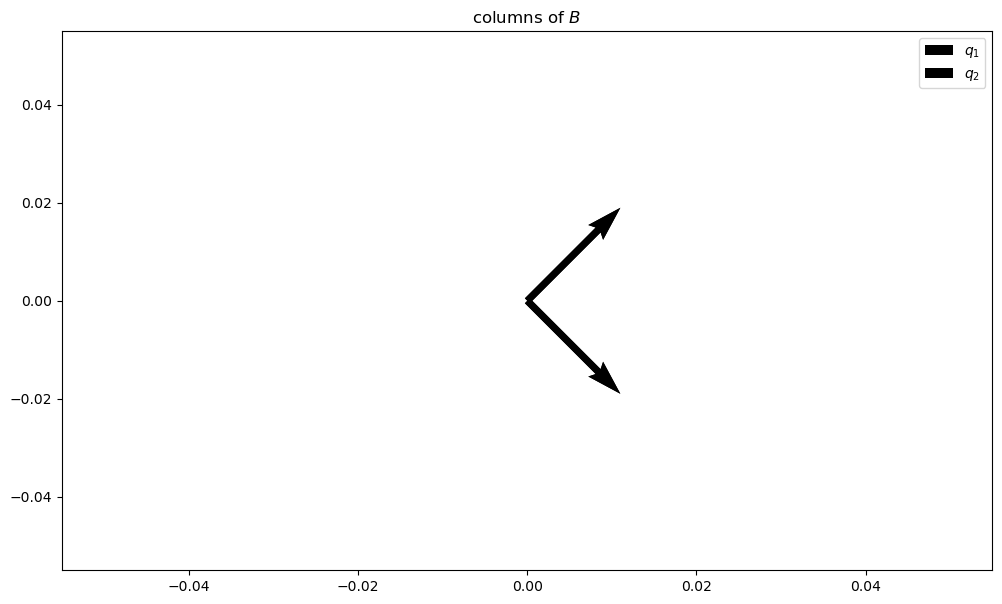

In [134]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.quiver([0, 0], [0, 0], B[0, 0], B[1, 0], scale=10, label="$q_{1}$")
ax.quiver([0, 0], [0, 0], B[0, 1], B[1, 1], scale=10, label="$q_{2}$")
plt.title("columns of $B$ ")
plt.legend()
plt.show()

We usually place our data in a design matrix $X$, which is a matrix where each row represents an individual sample. Consider the following example `X_`


In [135]:
samples = 200

u = np.array([[1.0, 1.0], [0.10, -0.10]]) / (2) ** (0.5)

X_ = np.dot(4 * np.random.randn(samples, 2), u) + 10
X_[0:5]

array([[13.35654123, 13.49335609],
       [10.974613  ,  9.13579263],
       [ 7.03337708,  6.83292566],
       [10.88102399, 10.65513322],
       [11.23558588, 12.41574907]])

In [136]:
Matrix(X_[:5, :5])

⎡13.3565412282778  13.4933560872443⎤
⎢                                  ⎥
⎢10.9746130043503  9.13579263024588⎥
⎢                                  ⎥
⎢7.03337707516574  6.83292566075808⎥
⎢                                  ⎥
⎢10.8810239895864  10.655133222993 ⎥
⎢                                  ⎥
⎣11.235585878265   12.4157490691655⎦

We can plot the samples:


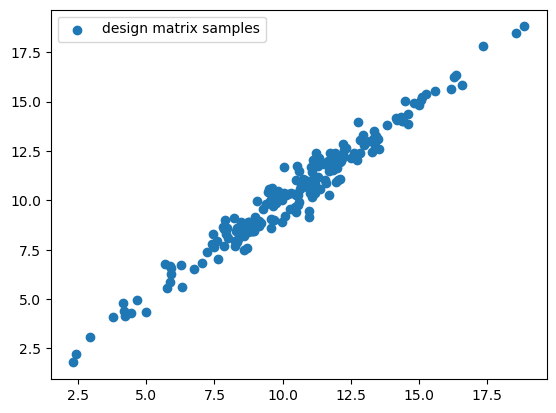

In [137]:
dict_ = {"design matrix samples": X_}
plot_2d(dict_)

We can find the shape of the design matrix:


In [138]:
N, D = X_.shape
print("number of smaples {}, dimensions is {}".format(N, D))

number of smaples 200, dimensions is 2


We can also perform lots of operations with Matrix multiplication, for example we can calculate the mean with the following:


In [139]:
mean = (np.ones((1, N)) / N) @ X_
mean

array([[10.43680397, 10.40411264]])

In [140]:
Matrix(np.ones((1, N)) / N)

[0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005   ↪

↪ 0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  ↪

↪  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005 ↪

↪   0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.00 ↪

↪ 5  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.0 ↪

↪ 05  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0. ↪

↪ 005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0 ↪

↪ .005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005   ↪

↪ 0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  ↪

↪  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005 ↪

↪   0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.00 ↪

↪ 5  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.005  0.0 ↪

↪ 05  0.005  0.0

We can verify the result in numpy.


In [141]:
X_.mean(axis=0)

array([10.43680397, 10.40411264])

### **Exercise 4**

Perform matrix multiplication using **no_mean** and **X\_**, save the result in **X**. Show the mean of **X** with respect to the rows is approximately zero:


In [142]:
I = np.identity(N)
col1 = np.ones((1, N))
row1 = np.ones((N, 1)) / N
no_mean = I - row1 @ col1
Matrix(no_mean)

⎡0.995   -0.005  -0.005  -0.005  -0.005  -0.005  -0.005  -0.005  -0.005  -0.00 ↪
⎢                                                                              ↪
⎢-0.005  0.995   -0.005  -0.005  -0.005  -0.005  -0.005  -0.005  -0.005  -0.00 ↪
⎢                                                                              ↪
⎢-0.005  -0.005  0.995   -0.005  -0.005  -0.005  -0.005  -0.005  -0.005  -0.00 ↪
⎢                                                                              ↪
⎢-0.005  -0.005  -0.005  0.995   -0.005  -0.005  -0.005  -0.005  -0.005  -0.00 ↪
⎢                                                                              ↪
⎢-0.005  -0.005  -0.005  -0.005  0.995   -0.005  -0.005  -0.005  -0.005  -0.00 ↪
⎢                                                                              ↪
⎢-0.005  -0.005  -0.005  -0.005  -0.005  0.995   -0.005  -0.005  -0.005  -0.00 ↪
⎢                                                                              ↪
⎢-0.005  -0.005  -0.005  -0.

In [143]:
# TO DO
X = no_mean @ X_
X.mean(axis=0)

array([-2.32203146e-15, -1.93012273e-15])

In [144]:
print("mean of X", X.mean(axis=0))

mean of X [-2.32203146e-15 -1.93012273e-15]


[[10.43680397 10.40411264]]


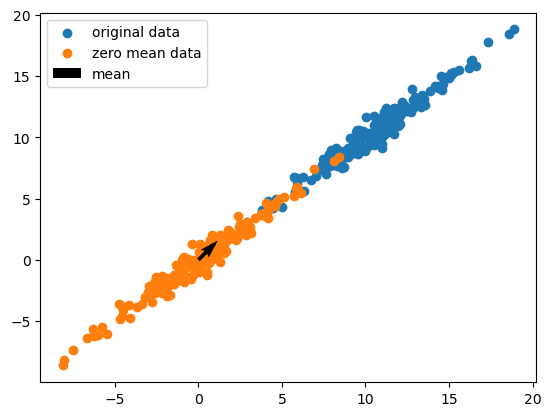

In [145]:
dict_ = {"original data": X_, "zero mean data": X, "mean": mean}
plot_2d(dict_)

As we subtracted the mean, we can calculate the empirical covariance matrix using matrix multiplication.


$C=\frac{1}{N}   \mathbf{X}^T \mathbf{X} $


In [146]:
C = X.T @ X / N
Matrix(C)

⎡8.41506126118846  8.17027244286397⎤
⎢                                  ⎥
⎣8.17027244286397  8.23442091838501⎦

We can see the matrix is full rank:


In [147]:
matrix_rank(C)

2

## **Eigen Decomposition**


### **Eigenvectors and Eigenvalues**


If the Matrix is full rank we can apply Eigen factorization or Eigen decomposition to it, so that it is represented in terms of its eigenvalues $\mathbf{\Lambda}$ and eigenvectors embedded in $\mathbf{Q}$, symbolically:


$\mathbf{A}=\mathbf{Q}\mathbf{\Lambda}\mathbf{Q}^{-1}$


We can obtain the Matrices as follows:


In [148]:
eigen_values, eigen_vectors = eig(A)

`eigen_values` is a vector so we convert it to a diagonal matrix  using the `np.diag` function


In [149]:
Matrix(np.diag(eigen_values))

⎡-1.30277563773199        0.0       ⎤
⎢                                   ⎥
⎣       0.0         2.30277563773199⎦

We can retrieve the original matrix as follows:


In [150]:
A = eigen_vectors @ np.diag(eigen_values) @ inv(eigen_vectors)
Matrix(A)

⎡-1.0  1.0⎤
⎢         ⎥
⎣1.0   2.0⎦

## **Factorization for PCA**


We can only use  eigen decomposition if the matrix is full rank, but even if the matrix is full rank, the eigenvalues and eigenvectors could be complex.

A useful application of the symmetric matrix ($S=S^{T}$) is where we want the eigenvalues to be real and the eigenvectors to be orthogonal. For example, the covariance matrix $C$ in PCA.


$\mathbf{C}=\mathbf{V}\mathbf{\Lambda}\mathbf{V}^{T}$


Using numpy,


In [151]:
eigen_values, eigen_vectors = eig(C)

We can perform PCA using factorization. To find the first principle component, we need to find the eigenvector with the largest eigenvalue.


In [152]:
v = eigen_vectors[:, np.argmax(eigen_values)].reshape(-1, 1)
v

array([[0.71100424],
       [0.70318772]])

We can calculate first principal component by finding the projection of the original data onto $\mathbf{v}$.


$\mathbf{Z}=\mathbf{X} \mathbf{v}$


In [153]:
Z = X @ v

### **Exercise 5**

Perform PCA with `n_components=1` on **X**. Store the transformed data in **X_transformed**. Also do an inverse_transform using the same fitted PCA object, store the result in **X\_**.


In [154]:
# TODO
pca = PCA(n_components=1)
X_transformed = pca.fit_transform(X)
X_ = pca.inverse_transform(X_transformed)

We can also  transform the data back to its original space, using matrix multiplication:


$\hat{X}=\mathbf{Z} \mathbf{v}^T$


### **Exercise 6**

Find the transform data back to its original space from the above equation, call it **Xhat**.


In [155]:
# TODO
Xhat = Z @ v.T

You can also check that the two methods give the same "inverse transform" result (**X\_** and **Xhat** will overlap in the plot) by running the following cell.


[[0.71100424 0.70318772]]


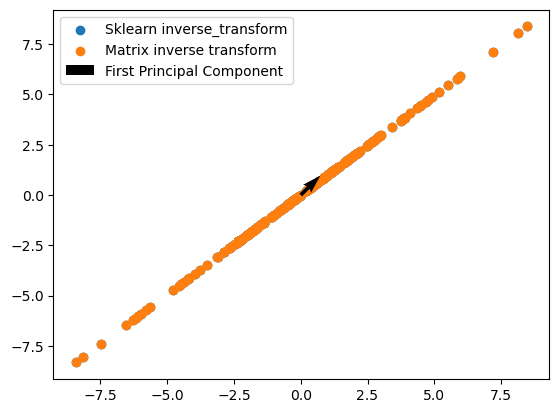

In [156]:
dict_ = {
    "Sklearn inverse_transform": X_,
    "Matrix inverse transform": Xhat,
    "First Principal Component": v.T,
}
plot_2d(dict_)

## **Authors**


<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Joseph Santarcangelo</a> Joseph has a Ph.D. in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.

Su Wu


### **Other Contributors**


[Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01) is a Data Science intern at IBM Skills Network, entering level-5 study in the Mathematics & Statistics undergraduate Coop program at McMaster University.


## **Change Log**


| Date (YYYY-MM-DD) | Version | Changed By  | Change Description  |
| ----------------- | ------- | ----------- | ------------------- |
| 2022-03-25        | 0.1     | Joseph S.   | Updated all content |
| 2022-05-26        | 0.1     | Roxanne Li  | Review and edit     |
| 2022-06-09        | 0.1     | Steve H.    | QA pass             |
| 2022-07-15        | 0.1     | Svitlana K. | Review and edit     |
| 2026-05-12        | 0.3     | Su Wu       | Documentation and code edits|


Copyright © 2021 IBM Corporation. All rights reserved.
